In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import joblib
import torch
from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')

# Mount Drive (Colab only)
try:
    import google.colab
    google.colab.drive.mount('/content/drive')
except ImportError:
    pass

DATA_ROOT = '/content/drive/MyDrive/CS1090B/project/data'

MODEL_DIR = os.path.join(DATA_ROOT, 'models')   # /content/drive/.../data/models
os.makedirs(MODEL_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
df = pd.read_parquet(os.path.join(DATA_ROOT, 'all_trades_features.parquet'))
df.head()

,ticker,yes_price,no_price,count,taker_side,created_time,volume,log_volume,target_price_5m,signed_ret_5m,...,position_in_range,dist_from_50,relative_volume,tick,run_length,volume_since_price_change,trades_last_60s,trades_last_300s,hour_sin,hour_cos
0,538APPROVEY-24DEC31-T37.9,1,99,304,yes,2025-01-01 02:57:15.947080+00:00,304.0,5.720312,1.0,0.0,...,NaN,0.98,NaN,0.0,0.0,5.720312,0.0,0.0,0.697790,0.716302
1,ACPI-24-B1.5,1,99,38,yes,2025-01-01 15:09:30.590342+00:00,38.0,3.663562,1.0,0.0,...,NaN,0.98,NaN,0.0,0.0,3.663562,0.0,0.0,-0.734322,-0.678801
2,ACPI-24-B1.5,1,99,12,yes,2025-01-01 15:09:30.590342+00:00,12.0,2.564949,1.0,0.0,...,NaN,0.98,0.315789,0.0,0.0,3.931826,0.0,0.0,-0.734322,-0.678801
3,ACPI-24-B1.5,2,98,42,yes,2025-01-01 15:23:33.219179+00:00,84.0,4.442651,1.0,-1.0,...,NaN,0.96,3.360000,1.0,1.0,4.442651,0.0,0.0,-0.774393,-0.632705
4,ACPI-24-B1.5,1,99,850,yes,2025-01-01 15:23:33.219179+00:00,850.0,6.746412,1.0,0.0,...,0.0,0.98,19.029850,-1.0,1.0,6.746412,0.0,0.0,-0.774393,-0.632705


In [ ]:
df.columns

Index(['ticker', 'yes_price', 'no_price', 'count', 'taker_side',
       'created_time', 'volume', 'log_volume', 'target_price_5m',
       'signed_ret_5m', 'abs_ret_5m', 'target_price_15m', 'signed_ret_15m',
       'abs_ret_15m', 'target_price_30m', 'signed_ret_30m', 'abs_ret_30m',
       'target_price_60m', 'signed_ret_60m', 'abs_ret_60m', 'split',
       'jump3_5m', 'jump3_15m', 'jump3_30m', 'jump3_60m', 'ticker_emb_0',
       'ticker_emb_1', 'ticker_emb_2', 'ticker_emb_3', 'ticker_emb_4',
       'ticker_emb_5', 'ticker_emb_6', 'ticker_emb_7', 'backward_ret_5m',
       'backward_abs_ret_5m', 'backward_ret_15m', 'backward_abs_ret_15m',
       'backward_ret_30m', 'backward_abs_ret_30m', 'backward_ret_60m',
       'backward_abs_ret_60m', 'recent_up_jumps_5m', 'recent_down_jumps_5m',
       'recent_up_jumps_15m', 'recent_down_jumps_15m', 'recent_up_jumps_30m',
       'recent_down_jumps_30m', 'recent_up_jumps_60m', 'recent_down_jumps_60m',
       'log_time_delta', 'ret_last_5', 'ret_last_1

In [ ]:
with pd.option_context('display.max_columns', None):
    display(df.iloc[[4]])

,ticker,yes_price,no_price,count,taker_side,created_time,volume,log_volume,target_price_5m,signed_ret_5m,abs_ret_5m,target_price_15m,signed_ret_15m,abs_ret_15m,target_price_30m,signed_ret_30m,abs_ret_30m,target_price_60m,signed_ret_60m,abs_ret_60m,split,jump3_5m,jump3_15m,jump3_30m,jump3_60m,ticker_emb_0,ticker_emb_1,ticker_emb_2,ticker_emb_3,ticker_emb_4,ticker_emb_5,ticker_emb_6,ticker_emb_7,backward_ret_5m,backward_abs_ret_5m,backward_ret_15m,backward_abs_ret_15m,backward_ret_30m,backward_abs_ret_30m,backward_ret_60m,backward_abs_ret_60m,recent_up_jumps_5m,recent_down_jumps_5m,recent_up_jumps_15m,recent_down_jumps_15m,recent_up_jumps_30m,recent_down_jumps_30m,recent_up_jumps_60m,recent_down_jumps_60m,log_time_delta,ret_last_5,ret_last_10,ret_last_20,position_in_range,dist_from_50,relative_volume,tick,run_length,volume_since_price_change,trades_last_60s,trades_last_300s,hour_sin,hour_cos
4,ACPI-24-B1.5,1,99,850,yes,2025-01-01 15:23:33.219179+00:00,850.0,6.746412,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,train,0.0,0.0,0.0,0.0,8.324194,-1.567758,2.414129,0.528984,-0.290241,1.881847,2.794698,-1.522861,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.98,19.02985,-1.0,1.0,6.746412,0.0,0.0,-0.774393,-0.632705


# LightGBM Model

In [4]:
import lightgbm as lgb
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score)

DATA_PATH = '/content/drive/MyDrive/CS1090B/project/data/all_trades_features.parquet'
df = pd.read_parquet(DATA_PATH)

# encode taker_side as small int (1 if "yes" took, else 0)
df['taker_side_int'] = (df['taker_side'] == 'yes').astype(np.int8)

HORIZONS = [5, 15, 30, 60]

# everything except identifiers, raw duplicates, and any leakage column
LEAK_COLS = (['ticker', 'created_time', 'split', 'count', 'volume',
              'no_price', 'taker_side']
             + [f'target_price_{h}m' for h in HORIZONS]
             + [f'signed_ret_{h}m'   for h in HORIZONS]
             + [f'abs_ret_{h}m'      for h in HORIZONS]
             + [f'jump3_{h}m'        for h in HORIZONS])

FEATURE_COLS = [c for c in df.columns if c not in LEAK_COLS]
print(f'{len(FEATURE_COLS)} features:')
print(FEATURE_COLS)
print(f'\nrows: {len(df):,}')
print(df['split'].value_counts(normalize=True).rename('frac'))

41 features:
['yes_price', 'log_volume', 'ticker_emb_0', 'ticker_emb_1', 'ticker_emb_2', 'ticker_emb_3', 'ticker_emb_4', 'ticker_emb_5', 'ticker_emb_6', 'ticker_emb_7', 'backward_ret_5m', 'backward_abs_ret_5m', 'backward_ret_15m', 'backward_abs_ret_15m', 'backward_ret_30m', 'backward_abs_ret_30m', 'backward_ret_60m', 'backward_abs_ret_60m', 'recent_up_jumps_5m', 'recent_down_jumps_5m', 'recent_up_jumps_15m', 'recent_down_jumps_15m', 'recent_up_jumps_30m', 'recent_down_jumps_30m', 'recent_up_jumps_60m', 'recent_down_jumps_60m', 'log_time_delta', 'ret_last_5', 'ret_last_10', 'ret_last_20', 'position_in_range', 'dist_from_50', 'relative_volume', 'tick', 'run_length', 'volume_since_price_change', 'trades_last_60s', 'trades_last_300s', 'hour_sin', 'hour_cos', 'taker_side_int']

rows: 63,801,798
split
train    0.8
test     0.2
Name: frac, dtype: float64


In [ ]:
def train_one_horizon(df, h, num_rounds=600, use_gpu=False, sample_frac=1.0, seed=42):
    """One LightGBM multiclass model for the jump3_{h}m target."""
    target_col = f'jump3_{h}m'

    # use the temporal split that's already in the dataframe
    train_mask = df['split'] == 'train'
    test_mask  = ~train_mask

    # carve last 10% of train (chronologically) for early-stopping validation
    train_df = df.loc[train_mask, ['created_time']]
    val_cut  = train_df['created_time'].quantile(0.9)
    val_mask = train_mask & (df['created_time'] >= val_cut)
    fit_mask = train_mask & ~val_mask

    # optional row subsample (for quick iteration on the full 64M rows)
    if sample_frac < 1.0:
        rng = np.random.default_rng(seed)
        keep = rng.random(len(df)) < sample_frac
        fit_mask &= keep
        val_mask &= keep

    # remap labels {-1, 0, 1} -> {0, 1, 2} for LightGBM multiclass
    label_map = {-1.0: 0, 0.0: 1, 1.0: 2}
    y = df[target_col].map(label_map).astype(np.int8).values

    X_fit  = df.loc[fit_mask,  FEATURE_COLS]
    X_val  = df.loc[val_mask,  FEATURE_COLS]
    X_test = df.loc[test_mask, FEATURE_COLS]
    y_fit, y_val, y_test = y[fit_mask.values], y[val_mask.values], y[test_mask.values]

    # inverse-frequency class weights (computed on fit set only)
    counts = np.bincount(y_fit, minlength=3).astype(np.float64)
    cls_w  = counts.sum() / (3 * np.maximum(counts, 1))
    sample_weight = cls_w[y_fit]

    print(f'\n=== horizon = {h}m ===')
    print(f'fit / val / test rows: {len(y_fit):,} / {len(y_val):,} / {len(y_test):,}')
    print(f'fit class counts: {dict(zip([-1,0,1], counts.astype(int)))}')
    print(f'class weights   : {dict(zip([-1,0,1], cls_w.round(3)))}')

    params = dict(
        objective='multiclass',
        num_class=3,
        metric='multi_logloss',
        learning_rate=0.05,
        num_leaves=255,
        min_data_in_leaf=500,
        feature_fraction=0.9,
        bagging_fraction=0.9,
        bagging_freq=1,
        verbose=-1,
        n_jobs=-1,
    )
    if use_gpu:
        params['device'] = 'gpu'

    dtr = lgb.Dataset(X_fit, y_fit, weight=sample_weight, free_raw_data=True)
    dva = lgb.Dataset(X_val, y_val, reference=dtr, free_raw_data=True)

    model = lgb.train(
        params, dtr,
        num_boost_round=num_rounds,
        valid_sets=[dva],
        valid_names=['val'],
        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)],
    )

    proba_test = model.predict(X_test, num_iteration=model.best_iteration)
    pred_test  = proba_test.argmax(axis=1)

    print(f'best_iter     : {model.best_iteration}')
    print(f'balanced acc  : {balanced_accuracy_score(y_test, pred_test):.4f}')
    print(f'f1 macro      : {f1_score(y_test, pred_test, average="macro"):.4f}')
    print(classification_report(y_test, pred_test,
                                target_names=['down (-1)', 'no jump (0)', 'up (+1)'],
                                digits=4))
    print('Confusion matrix (rows = true, cols = pred):')
    print(confusion_matrix(y_test, pred_test))

    return {'model': model, 'proba_test': proba_test, 'y_test': y_test}

In [ ]:
import matplotlib.dates as mdates

def plot_top_confidence_examples(df, results, h=30,
                                 n_per_class=3,
                                 top_k_pool=2000,
                                 context_min=None,
                                 forward_pad_min=5):
    """For horizon h, plot trade-price trajectories around the highest-confidence
    predictions for each of the three classes (using different tickers per row)."""

    if context_min is None:
        context_min = max(2 * h, 20)

    # --- align proba rows with original df positions ---
    test_mask = (df['split'] == 'test').values
    test_positions = np.flatnonzero(test_mask)      # int positions into df
    proba = results[h]['proba_test']                # (n_test, 3) in same order
    target_col = f'jump3_{h}m'

    # class label conventions used during training:
    #   class 0 -> jump3 = -1 (down),  1 -> 0 (no jump),  2 -> +1 (up)
    cls_to_label = {0: -1, 1: 0, 2: 1}
    class_names  = {0: 'down (-1)', 1: 'no jump (0)', 2: 'up (+1)'}
    class_colors = {0: '#26a69a',   1: '#888888',     2: '#ef5350'}

    # plotting order: up, down, no-jump
    row_classes = [2, 0, 1]

    fig, axes = plt.subplots(3, n_per_class,
                             figsize=(5 * n_per_class, 11),
                             squeeze=False)

    for row, cls in enumerate(row_classes):
        # rank test rows by P(class=cls) descending; restrict to a pool then dedup tickers
        pool = np.argsort(-proba[:, cls])[:top_k_pool]
        chosen = []
        seen_tickers = set()
        for i in pool:
            orig_pos = test_positions[i]
            ticker = df['ticker'].iloc[orig_pos]
            if ticker in seen_tickers:
                continue
            seen_tickers.add(ticker)
            chosen.append((orig_pos, i))
            if len(chosen) == n_per_class:
                break

        for col, (orig_pos, test_i) in enumerate(chosen):
            ax = axes[row, col]
            ticker  = df['ticker'].iloc[orig_pos]
            t_pred  = df['created_time'].iloc[orig_pos]
            p_now   = df['yes_price'].iloc[orig_pos]
            true_lbl = int(df[target_col].iloc[orig_pos])
            prob    = proba[test_i, cls]

            # slice this ticker's trades in [t_pred - context, t_pred + h + pad]
            t_start = t_pred - pd.Timedelta(minutes=context_min)
            t_end   = t_pred + pd.Timedelta(minutes=h + forward_pad_min)
            tk_mask = (df['ticker'] == ticker) & \
                      (df['created_time'] >= t_start) & \
                      (df['created_time'] <= t_end)
            sub = df.loc[tk_mask, ['created_time', 'yes_price']]

            # price path
            ax.plot(sub['created_time'], sub['yes_price'],
                    color='#1f77b4', linewidth=0.8, alpha=0.6)
            ax.scatter(sub['created_time'], sub['yes_price'],
                       s=6, color='#1f77b4', alpha=0.4)

            # mark prediction point and target horizon point
            t_target = t_pred + pd.Timedelta(minutes=h)
            p_target = df[f'target_price_{h}m'].iloc[orig_pos]

            ax.axvspan(t_pred, t_target, alpha=0.08, color=class_colors[cls])
            ax.axvline(t_pred,   color='black',            ls='--', lw=1, alpha=0.7)
            ax.axvline(t_target, color=class_colors[cls],  ls=':',  lw=1, alpha=0.7)
            ax.scatter([t_pred],   [p_now],    s=70, color='black',
                       zorder=10, label=f't₀  @ {p_now:.0f}¢')
            ax.scatter([t_target], [p_target], s=110, color=class_colors[cls],
                       marker='*', zorder=10,
                       label=f't+{h}m @ {p_target:.0f}¢')

            correct = (cls_to_label[cls] == true_lbl)
            mark = '✓' if correct else '✗'
            ax.set_title(
                f'{ticker[:32]}\n'
                f'P({class_names[cls]}) = {prob:.3f}   '
                f'true = {true_lbl:+d} {mark}',
                fontsize=9,
            )

            ax.set_ylim(0, 100)
            ax.grid(alpha=0.3)
            ax.legend(loc='best', fontsize=7, framealpha=0.85)
            ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=4))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
            ax.tick_params(axis='x', labelsize=7, rotation=30)
            ax.tick_params(axis='y', labelsize=8)

        axes[row, 0].set_ylabel(f'{class_names[cls]}\nyes_price (¢)', fontsize=10)

    fig.suptitle(
        f'Top-confidence predictions per class — {h}-minute horizon\n'
        f'(context: {context_min}min back, dashed line = t₀, star = realized price at t₀+{h}m)',
        fontsize=12, y=1.00,
    )
    plt.tight_layout()
    plt.show()


=== horizon = 5m ===
fit / val / test rows: 2,297,716 / 255,131 / 12,760,360
fit class counts: {-1: np.int64(191144), 0: np.int64(1914110), 1: np.int64(192462)}
class weights   : {-1: np.float64(4.007), 0: np.float64(0.4), 1: np.float64(3.98)}
Training until validation scores don't improve for 30 rounds
[50]	val's multi_logloss: 0.711928
[100]	val's multi_logloss: 0.69309
[150]	val's multi_logloss: 0.682134
[200]	val's multi_logloss: 0.674025
[250]	val's multi_logloss: 0.666043
[300]	val's multi_logloss: 0.659235
Did not meet early stopping. Best iteration is:
[300]	val's multi_logloss: 0.659235
best_iter     : 300
balanced acc  : 0.5476
f1 macro      : 0.4735
              precision    recall  f1-score   support

   down (-1)     0.2290    0.4666    0.3072   1169905
 no jump (0)     0.9508    0.7223    0.8209  10423338
     up (+1)     0.2155    0.4539    0.2923   1167117

    accuracy                         0.6743  12760360
   macro avg     0.4651    0.5476    0.4735  12760360
weig

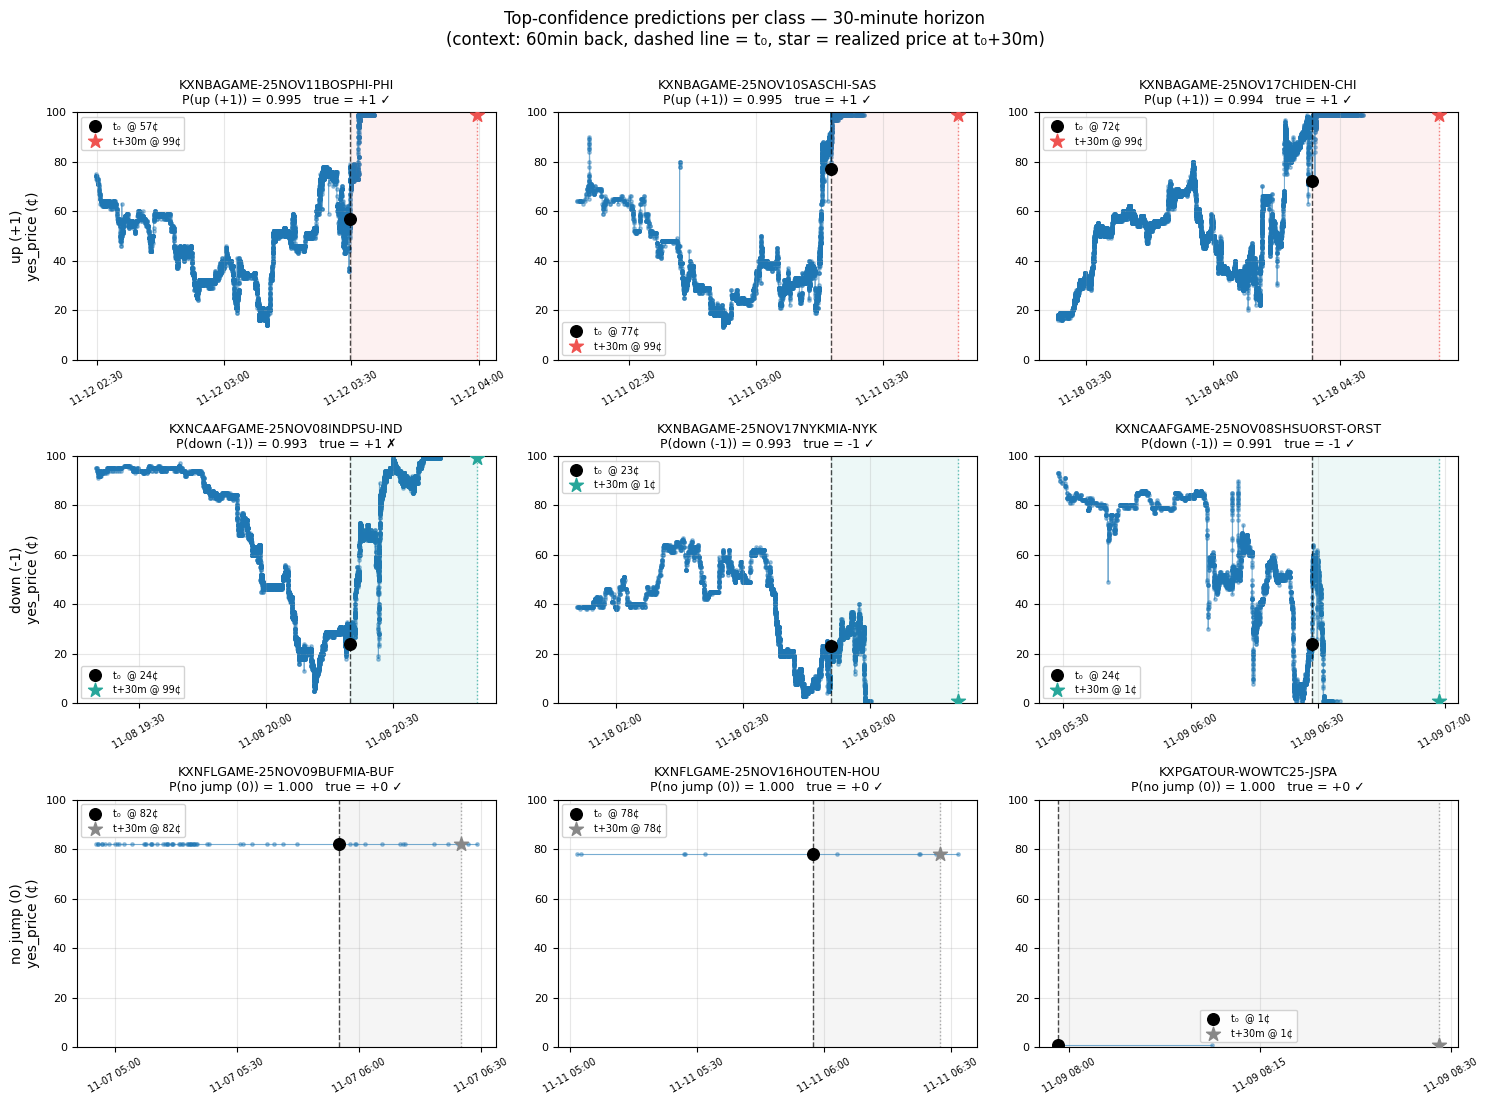

In [ ]:
results_sample = {}
for h in HORIZONS:
    results_sample[h] = train_one_horizon(df, h, sample_frac=0.05, num_rounds=300)

plot_top_confidence_examples(df, results_sample, h=30, n_per_class=3)



=== horizon = 5m ===
fit / val / test rows: 45,937,294 / 5,104,144 / 12,760,360
fit class counts: {-1: np.int64(3824570), 0: np.int64(38261552), 1: np.int64(3851172)}
class weights   : {-1: np.float64(4.004), 0: np.float64(0.4), 1: np.float64(3.976)}
Training until validation scores don't improve for 30 rounds
[50]	val's multi_logloss: 0.712535
[100]	val's multi_logloss: 0.693078
[150]	val's multi_logloss: 0.681922
[200]	val's multi_logloss: 0.672974
[250]	val's multi_logloss: 0.664388
[300]	val's multi_logloss: 0.659142
[350]	val's multi_logloss: 0.653257
[400]	val's multi_logloss: 0.648668
[450]	val's multi_logloss: 0.644267
[500]	val's multi_logloss: 0.640424
[550]	val's multi_logloss: 0.636613
[600]	val's multi_logloss: 0.633388
[650]	val's multi_logloss: 0.630473
[700]	val's multi_logloss: 0.627657
[750]	val's multi_logloss: 0.62505
[800]	val's multi_logloss: 0.622174
[850]	val's multi_logloss: 0.619698
[900]	val's multi_logloss: 0.617461
Did not meet early stopping. Best iterati

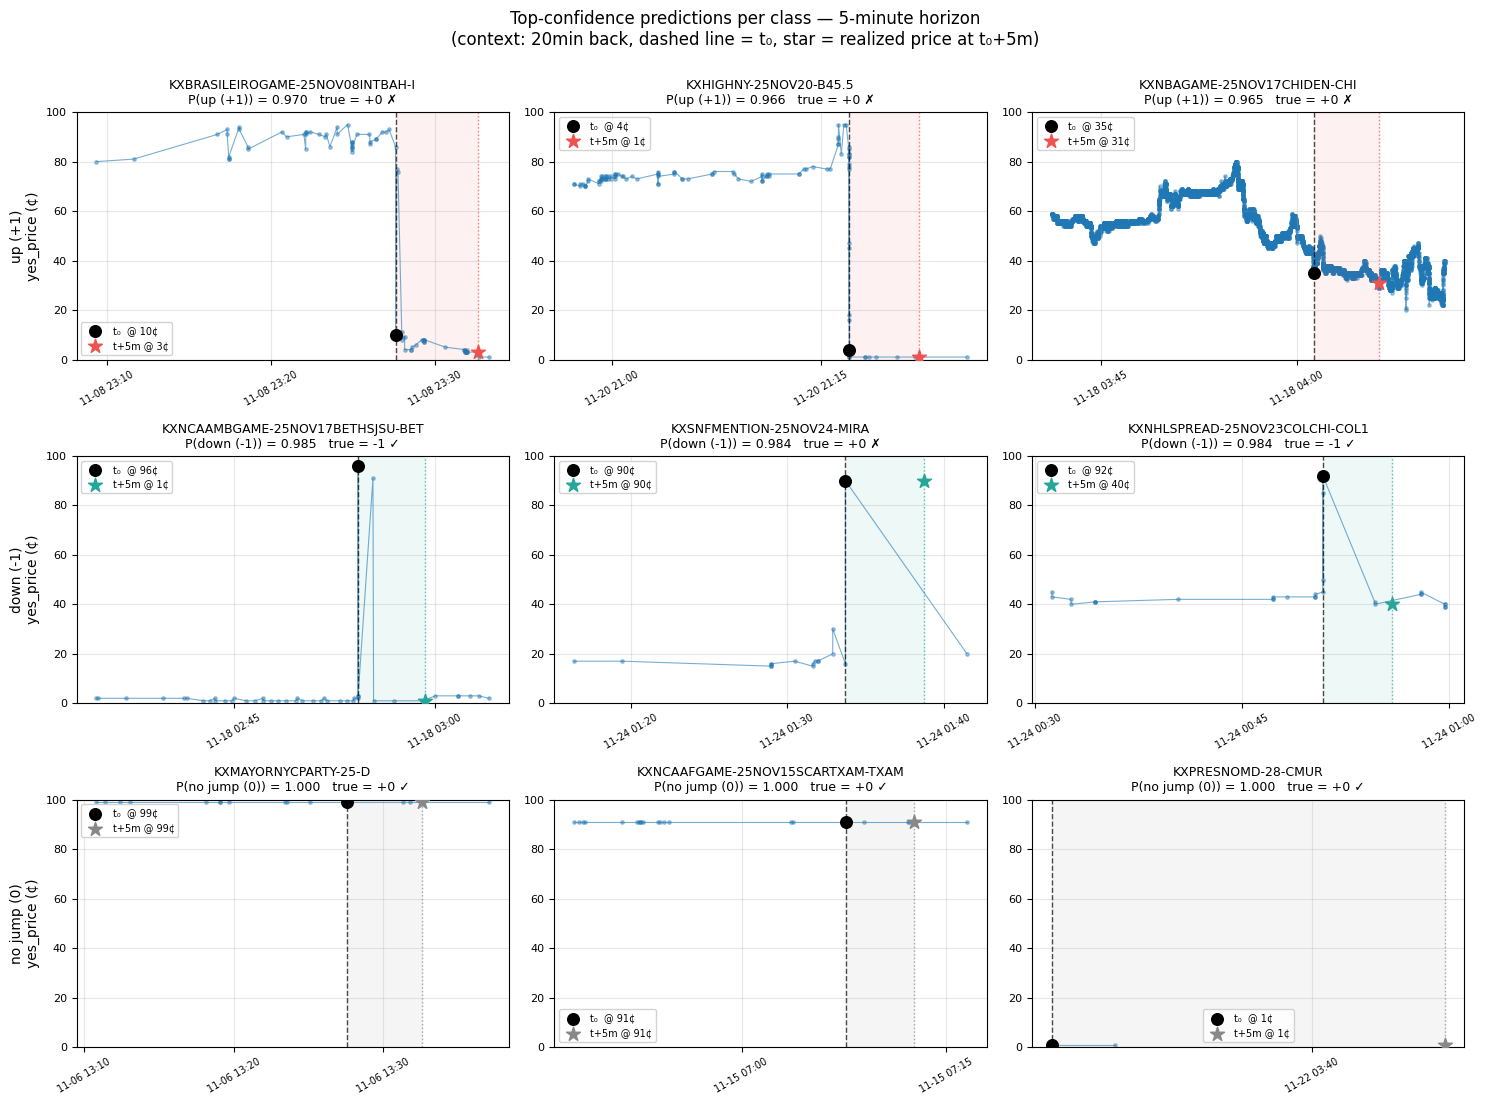


=== horizon = 15m ===
fit / val / test rows: 45,937,294 / 5,104,144 / 12,760,360
fit class counts: {-1: np.int64(4256851), 0: np.int64(37401059), 1: np.int64(4279384)}
class weights   : {-1: np.float64(3.597), 0: np.float64(0.409), 1: np.float64(3.578)}
Training until validation scores don't improve for 30 rounds
[50]	val's multi_logloss: 0.680314
[100]	val's multi_logloss: 0.654876
[150]	val's multi_logloss: 0.640311
[200]	val's multi_logloss: 0.628541
[250]	val's multi_logloss: 0.620848
[300]	val's multi_logloss: 0.614611
[350]	val's multi_logloss: 0.608322
[400]	val's multi_logloss: 0.603701
[450]	val's multi_logloss: 0.599307
[500]	val's multi_logloss: 0.595356
[550]	val's multi_logloss: 0.592307
[600]	val's multi_logloss: 0.589257
[650]	val's multi_logloss: 0.586538
[700]	val's multi_logloss: 0.584102
[750]	val's multi_logloss: 0.581424
[800]	val's multi_logloss: 0.579536
[850]	val's multi_logloss: 0.57737
[900]	val's multi_logloss: 0.575486
Did not meet early stopping. Best iter

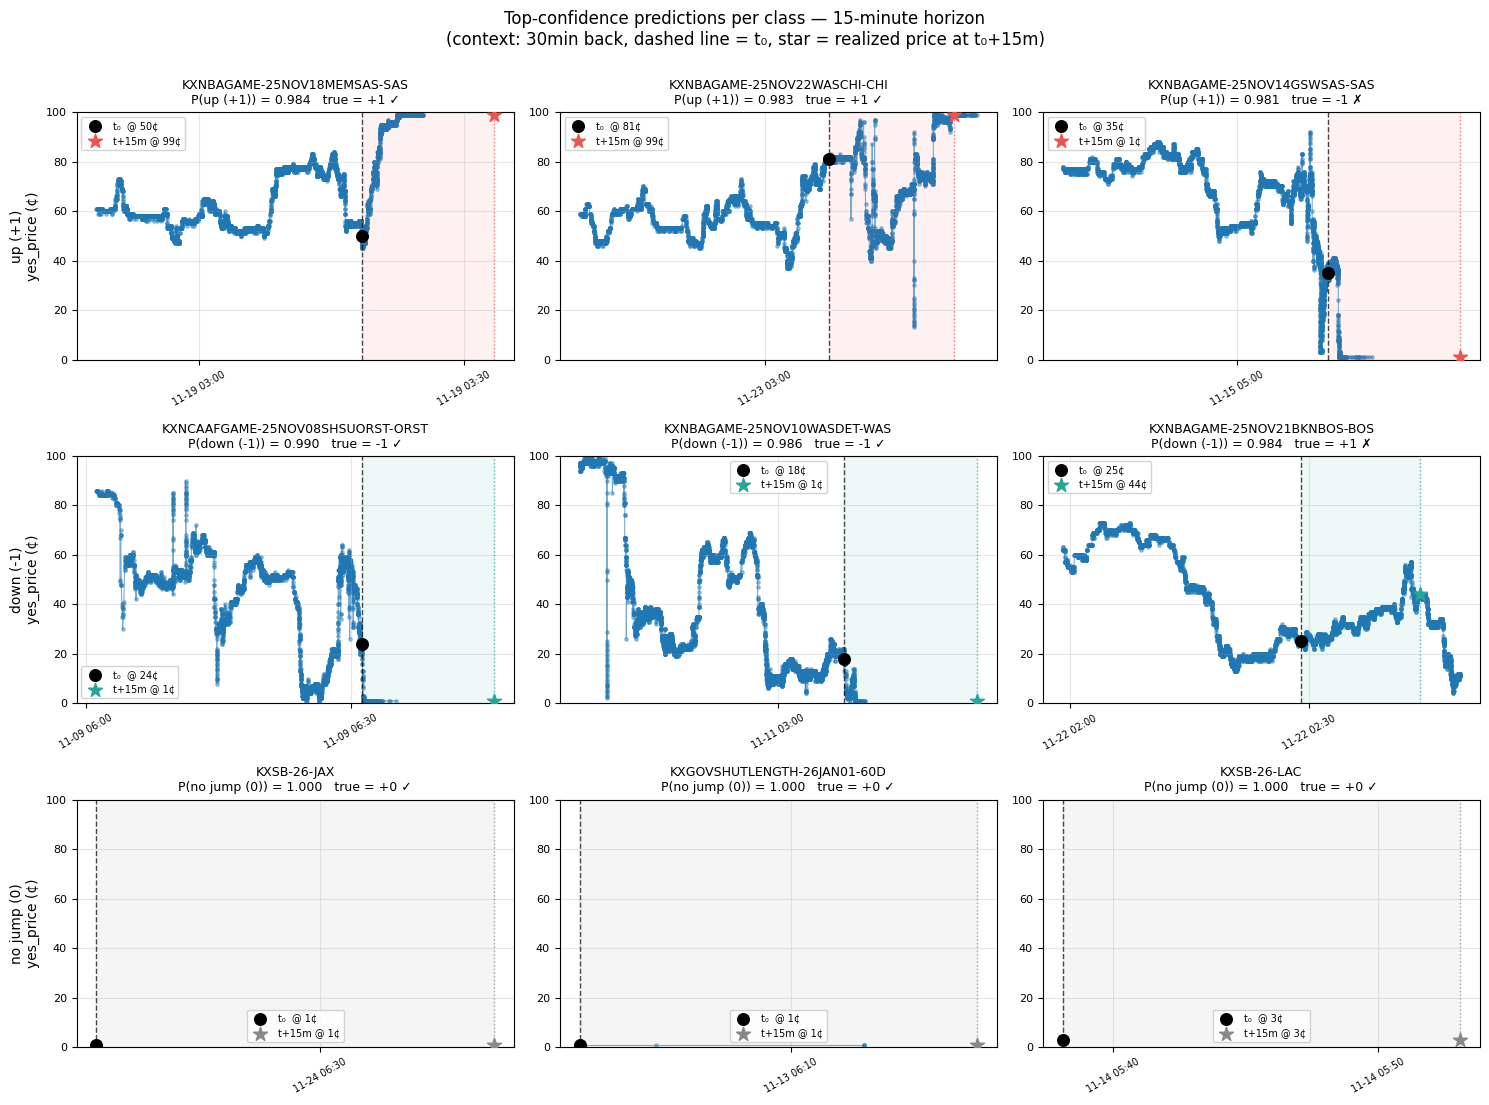


=== horizon = 30m ===
fit / val / test rows: 45,937,294 / 5,104,144 / 12,760,360
fit class counts: {-1: np.int64(4613805), 0: np.int64(36919391), 1: np.int64(4404098)}
class weights   : {-1: np.float64(3.319), 0: np.float64(0.415), 1: np.float64(3.477)}
Training until validation scores don't improve for 30 rounds
[50]	val's multi_logloss: 0.651829
[100]	val's multi_logloss: 0.622918
[150]	val's multi_logloss: 0.607906
[200]	val's multi_logloss: 0.597993
[250]	val's multi_logloss: 0.590938
[300]	val's multi_logloss: 0.586006
[350]	val's multi_logloss: 0.581854
[400]	val's multi_logloss: 0.578357
[450]	val's multi_logloss: 0.575061
[500]	val's multi_logloss: 0.572594
[550]	val's multi_logloss: 0.570332
[600]	val's multi_logloss: 0.568658
[650]	val's multi_logloss: 0.567321
[700]	val's multi_logloss: 0.565658
[750]	val's multi_logloss: 0.564584
[800]	val's multi_logloss: 0.5636
[850]	val's multi_logloss: 0.562895
[900]	val's multi_logloss: 0.561613
Did not meet early stopping. Best itera

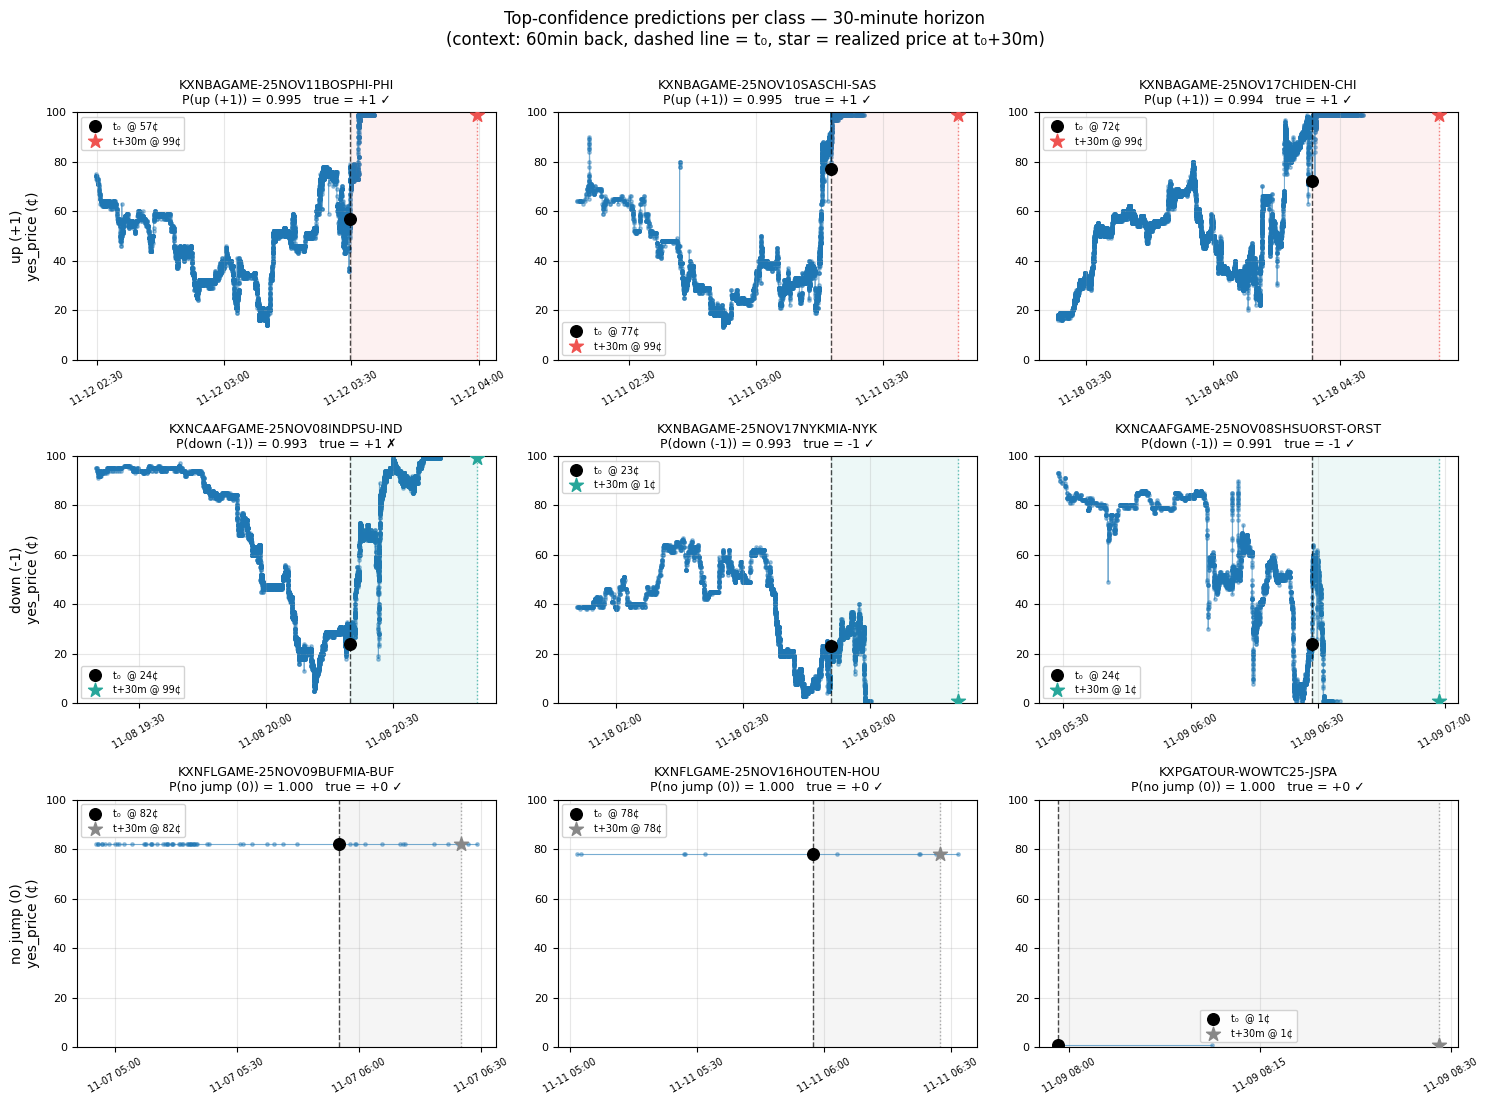


=== horizon = 60m ===
fit / val / test rows: 45,937,294 / 5,104,144 / 12,760,360
fit class counts: {-1: np.int64(4851296), 0: np.int64(36688775), 1: np.int64(4397223)}
class weights   : {-1: np.float64(3.156), 0: np.float64(0.417), 1: np.float64(3.482)}
Training until validation scores don't improve for 30 rounds
[50]	val's multi_logloss: 0.625595
[100]	val's multi_logloss: 0.588143
[150]	val's multi_logloss: 0.571578
[200]	val's multi_logloss: 0.563049
[250]	val's multi_logloss: 0.55698
[300]	val's multi_logloss: 0.552611
[350]	val's multi_logloss: 0.548891
[400]	val's multi_logloss: 0.546491
[450]	val's multi_logloss: 0.544494
[500]	val's multi_logloss: 0.54341
[550]	val's multi_logloss: 0.541918
[600]	val's multi_logloss: 0.541556
[650]	val's multi_logloss: 0.541236
[700]	val's multi_logloss: 0.540818
[750]	val's multi_logloss: 0.540393
[800]	val's multi_logloss: 0.539758
[850]	val's multi_logloss: 0.53957
[900]	val's multi_logloss: 0.539426
Did not meet early stopping. Best iterat

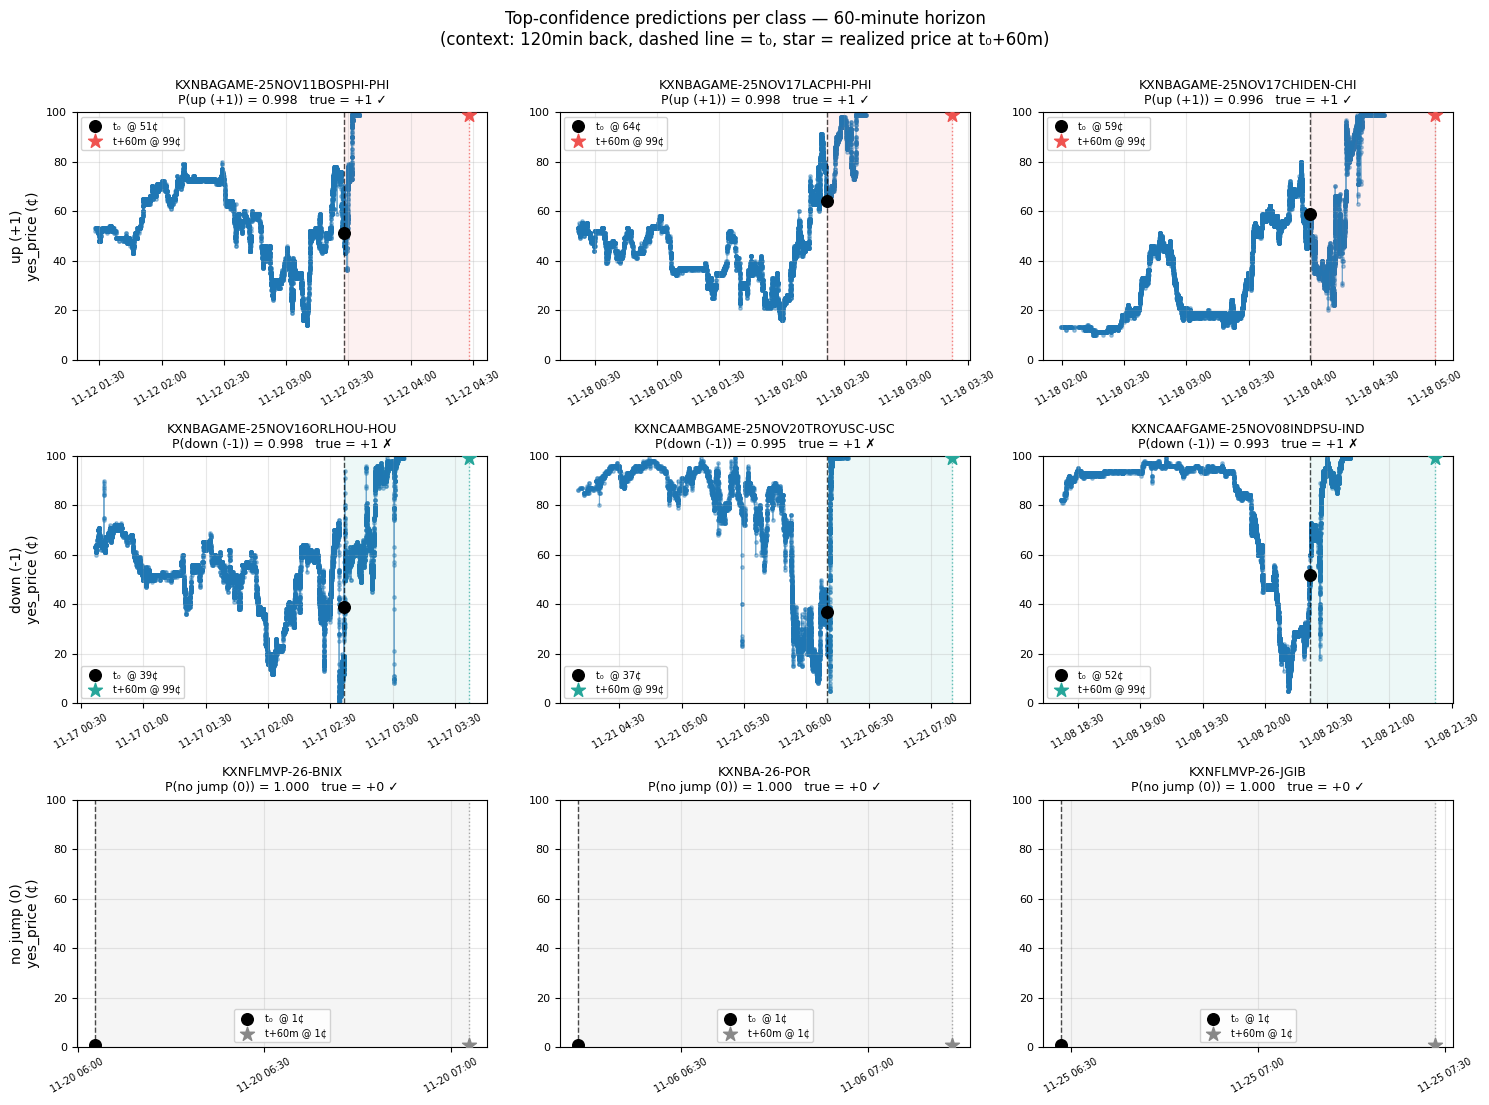

In [ ]:
results = {}
for h in HORIZONS:
    results[h] = train_one_horizon(df, h, sample_frac=1.0, num_rounds=900)
    plot_top_confidence_examples(df, results_sample, h=h, n_per_class=3)




In [ ]:


for h, res in results.items():
    out_path = os.path.join(MODEL_DIR, f'lgbm_jump3_{h}m.txt')
    res['model'].save_model(out_path)
    print(f'saved {out_path}  ({os.path.getsize(out_path) / 1e6:.1f} MB)')

joblib.dump(FEATURE_COLS, os.path.join(MODEL_DIR, 'feature_cols.joblib'))
print('saved feature_cols.joblib')

saved /content/drive/MyDrive/CS1090B/project/data/models/lgbm_jump3_5m.txt  (76.9 MB)
saved /content/drive/MyDrive/CS1090B/project/data/models/lgbm_jump3_15m.txt  (76.7 MB)
saved /content/drive/MyDrive/CS1090B/project/data/models/lgbm_jump3_30m.txt  (76.9 MB)
saved /content/drive/MyDrive/CS1090B/project/data/models/lgbm_jump3_60m.txt  (76.1 MB)
saved feature_cols.joblib


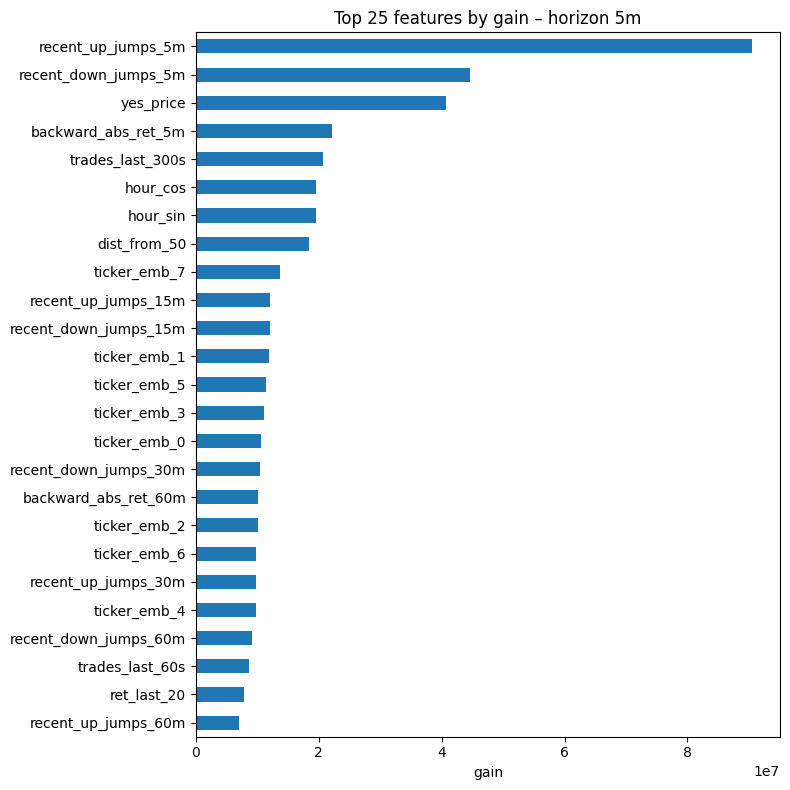

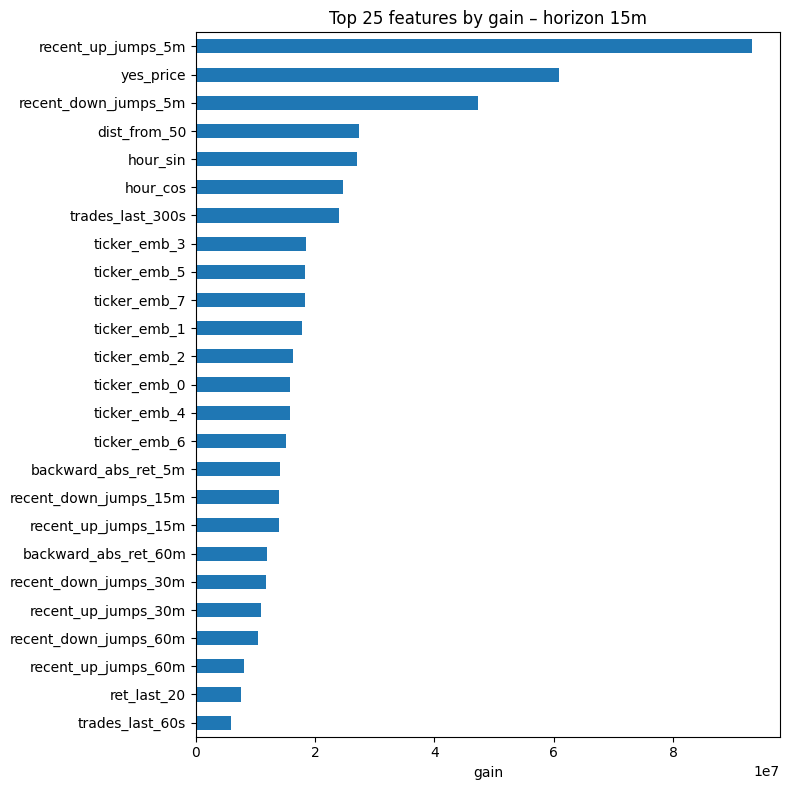

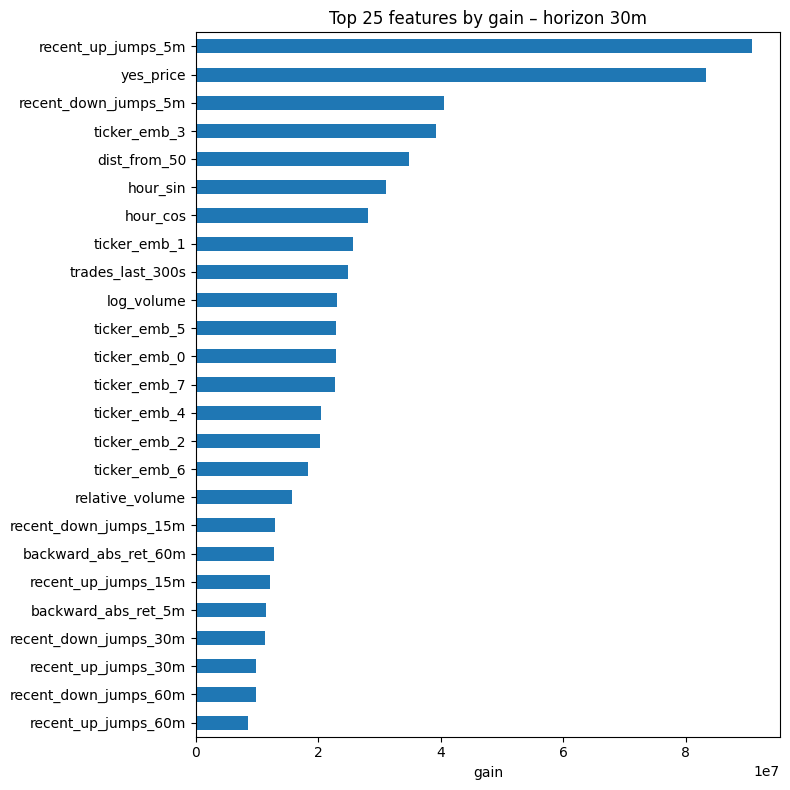

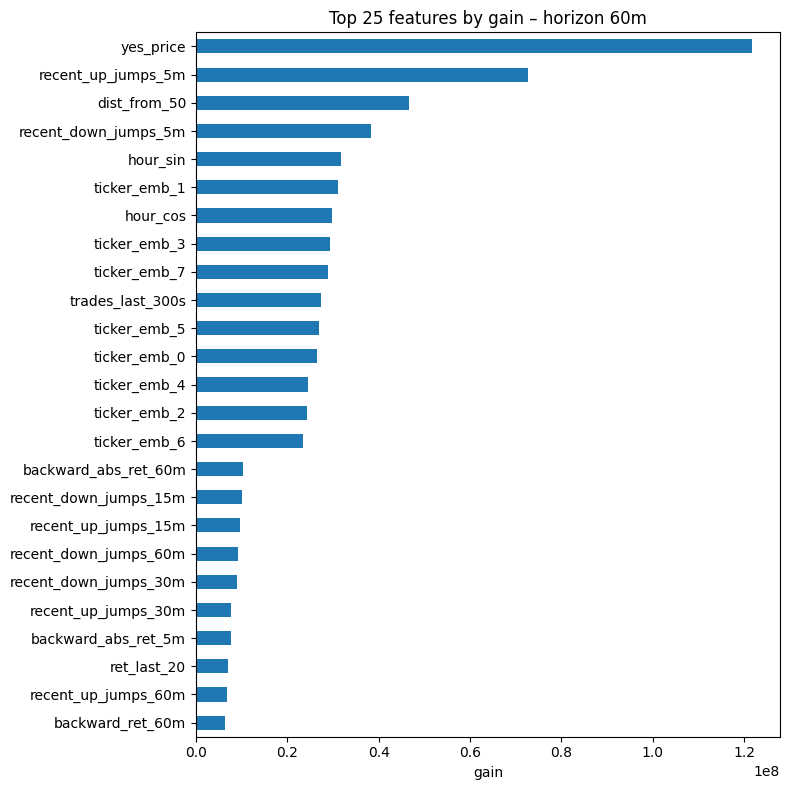

In [ ]:
def plot_importance(model, h, top_n=25):
    imp = pd.Series(model.feature_importance(importance_type='gain'),
                    index=FEATURE_COLS).sort_values()
    imp.tail(top_n).plot.barh(figsize=(8, 8))
    plt.title(f'Top {top_n} features by gain – horizon {h}m')
    plt.xlabel('gain')
    plt.tight_layout()
    plt.show()

for h in HORIZONS:
    plot_importance(results[h]['model'], h)

# LSTM

In [6]:
import os, math, time, joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score)

DATA_ROOT  = '/content/drive/MyDrive/CS1090B/project/data'
DATA_PATH  = os.path.join(DATA_ROOT, 'all_trades_features.parquet')
MODEL_DIR  = os.path.join(DATA_ROOT, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}',
      f'GPU: {torch.cuda.get_device_name(0)}' if DEVICE == 'cuda' else '')

# ---- Config ----
HORIZONS      = [5, 15, 30, 60]
SEQ_LEN       = 32
STRIDE        = 16
HIDDEN_SIZE   = 192
NUM_LAYERS    = 2
DROPOUT       = 0.2
LR            = 3e-4
EPOCHS        = 10
BATCH_SIZE    = 256
WARMUP_STEPS  = 500
GRAD_CLIP     = 1.0
SEED          = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [7]:
df = pd.read_parquet(DATA_PATH)
df['created_time'] = pd.to_datetime(df['created_time'], utc=True)
df['taker_side_int'] = (df['taker_side'] == 'yes').astype(np.int8)

# Same exclusion logic as LightGBM
LEAK_COLS = (['ticker', 'created_time', 'split', 'count', 'volume',
              'no_price', 'taker_side']
             + [f'target_price_{h}m' for h in HORIZONS]
             + [f'signed_ret_{h}m'   for h in HORIZONS]
             + [f'abs_ret_{h}m'      for h in HORIZONS]
             + [f'jump3_{h}m'        for h in HORIZONS])

FEATURE_COLS = [c for c in df.columns if c not in LEAK_COLS]
TARGET_COLS  = [f'jump3_{h}m' for h in HORIZONS]

print(f'{len(FEATURE_COLS)} features, {len(TARGET_COLS)} targets')
print(f'rows: {len(df):,}')
print(df['split'].value_counts(normalize=True).rename('frac'))

# ---- Sort by ticker then time for correct windowing ----
df = df.sort_values(['ticker', 'created_time'], kind='stable').reset_index(drop=True)

# ---- Compute z-score stats from train fold only ----
train_mask = df['split'] == 'train'
# Use fit-fold (first 90% of train) for stats to mirror LightGBM exactly
val_cut    = df.loc[train_mask, 'created_time'].quantile(0.9)
fit_mask   = train_mask & (df['created_time'] < val_cut)

feat_mean = df.loc[fit_mask, FEATURE_COLS].mean().astype(np.float32)
feat_std  = df.loc[fit_mask, FEATURE_COLS].std().replace(0, 1.0).astype(np.float32)
print('z-score stats computed from fit fold')

41 features, 4 targets
rows: 63,801,798
split
train    0.8
test     0.2
Name: frac, dtype: float64
z-score stats computed from fit fold


In [8]:
class KalshiSequenceDataset(Dataset):
    """Strict per-ticker sliding windows of length SEQ_LEN.

    For each ticker, generate windows [t-L+1 ... t] with stride S.
    A window is dropped if any feature or target in it is NaN/inf.
    The prediction is made at position t (the last trade in the window).
    """
    def __init__(self, df, feature_cols, target_cols, mean, std,
                 seq_len=32, stride=16, split=None):
        self.seq_len = seq_len
        self.feature_cols = feature_cols
        self.target_cols  = target_cols

        if split is not None:
            df = df[df['split'] == split].reset_index(drop=True)

        # Pre-normalize the feature matrix once (memory: 64M * 40 * 4 = ~10 GB).
        # If this OOMs, normalize per-window inside __getitem__ instead.
        feats = ((df[feature_cols].values - mean.values) / std.values).astype(np.float32)
        targets = df[target_cols].values.astype(np.float32)
        # Remap {-1, 0, +1} -> {0, 1, 2} for CrossEntropy
        targets = (targets + 1).astype(np.int64)

        # Build per-ticker boundaries
        codes = pd.factorize(df['ticker'])[0]
        change = np.where(np.diff(codes) != 0)[0] + 1
        starts = np.concatenate([[0], change])
        ends   = np.concatenate([change, [len(df)]])

        # Generate valid window-end indices per ticker
        ends_list = []
        for s, e in zip(starts, ends):
            # earliest valid end = s + seq_len - 1
            # latest valid end   = e - 1
            first_end = s + seq_len - 1
            last_end  = e - 1
            if first_end > last_end:
                continue
            ends_list.append(np.arange(first_end, last_end + 1, stride))
        candidate_ends = np.concatenate(ends_list) if ends_list else np.array([], dtype=np.int64)

        # Fill NaN/inf in features with 0 (= train-fold mean after z-scoring),
      # but still drop windows where the TARGET is undefined since that's the label.
        feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)

        valid = []
        for t in candidate_ends:
            if np.isfinite(targets[t]).all():
                valid.append(t)
        self.window_ends = np.array(valid, dtype=np.int64)
        self.feats   = feats
        self.targets = targets
        print(f'[{split}] {len(self.window_ends):,} valid windows '
              f'(dropped {len(candidate_ends) - len(self.window_ends):,})')

    def __len__(self):
        return len(self.window_ends)

    def __getitem__(self, idx):
        t = self.window_ends[idx]
        s = t - self.seq_len + 1
        x = self.feats[s:t+1]              # [L, F]
        y = self.targets[t]                # [n_horizons]
        return torch.from_numpy(x), torch.from_numpy(y)


# Build datasets (this takes a few minutes on 64M rows; the NaN filter is the slow part)
print('Building train set...')
train_ds = KalshiSequenceDataset(df, FEATURE_COLS, TARGET_COLS,
                                 feat_mean, feat_std,
                                 seq_len=SEQ_LEN, stride=STRIDE, split='train')
print('Building test set...')
test_ds  = KalshiSequenceDataset(df, FEATURE_COLS, TARGET_COLS,
                                 feat_mean, feat_std,
                                 seq_len=SEQ_LEN, stride=STRIDE, split='test')

Building train set...
[train] 2,951,618 valid windows (dropped 0)
Building test set...
[test] 742,185 valid windows (dropped 0)


In [9]:
class LSTMJumpPredictor(nn.Module):
    """Unidirectional LSTM sequence classifier for one horizon's jump prediction."""
    def __init__(self, n_features=40, hidden_size=192, num_layers=2,
                 n_classes=3, dropout=0.2):
        super().__init__()
        self.n_classes = n_classes

        self.in_proj = nn.Linear(n_features, hidden_size)
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.head_dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, n_classes)
        self._init_weights()

    def _init_weights(self):
        for name, p in self.lstm.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)
                n = p.size(0)
                p.data[n // 4 : n // 2].fill_(1.0)   # forget-gate bias = 1
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, x):
        x = self.in_proj(x)
        out, _ = self.lstm(x)
        last = self.norm(out[:, -1, :])
        last = self.head_dropout(last)
        return self.head(last)            # [B, 3]

In [ ]:
# Compute per-horizon class weights from the training set
class_weights = []
print('Class weights per horizon:')
for h_idx, h in enumerate(HORIZONS):
    y_train = train_ds.targets[train_ds.window_ends][:, h_idx]
    counts = np.bincount(y_train, minlength=3).astype(np.float64)
    w = counts.sum() / (3 * np.maximum(counts, 1))
    class_weights.append(torch.tensor(w, dtype=torch.float32, device=DEVICE))
    print(f'  {h:>2}m  counts={counts.astype(int).tolist()}  weights={w.round(3).tolist()}')

# One CE loss per horizon
losses_fn = [nn.CrossEntropyLoss(weight=class_weights[i]) for i in range(len(HORIZONS))]

Class weights per horizon:
   5m  counts=[221173, 1760896, 221284]  weights=[3.321, 0.417, 3.319]
  15m  counts=[244699, 1715550, 243104]  weights=[3.001, 0.428, 3.021]
  30m  counts=[261183, 1694135, 248035]  weights=[2.812, 0.434, 2.961]
  60m  counts=[269569, 1691106, 242678]  weights=[2.725, 0.434, 3.026]


In [ ]:
# ---- Shared train/val split (same for every horizon) ----
all_ends = train_ds.window_ends
end_times = df['created_time'].values[all_ends]
fit_idx = np.where(end_times <  np.datetime64(val_cut))[0]
val_idx = np.where(end_times >= np.datetime64(val_cut))[0]

from torch.utils.data import Subset
fit_ds = Subset(train_ds, fit_idx.tolist())
val_ds = Subset(train_ds, val_idx.tolist())
print(f'fit windows: {len(fit_ds):,}   val windows: {len(val_ds):,}')

fit_loader = DataLoader(fit_ds, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                        num_workers=2, pin_memory=True)

# ---- Training config ----
MAX_EPOCHS = 30
PATIENCE   = 3


def train_one_horizon(horizon_idx, horizon_min):
    """Train one LSTM for a single horizon. Returns the path to the best checkpoint."""
    print(f'\n{"="*60}')
    print(f'Training LSTM for horizon = {horizon_min}m  (index {horizon_idx})')
    print(f'{"="*60}')

    # ---- Fresh model + optimizer per horizon ----
    model_h = LSTMJumpPredictor(
        n_features=len(FEATURE_COLS),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        n_classes=3,
        dropout=DROPOUT,
    ).to(DEVICE)
    n_params = sum(p.numel() for p in model_h.parameters() if p.requires_grad)
    print(f'  trainable params: {n_params:,}')

    # ---- This horizon's class-weighted CE ----
    loss_fn = nn.CrossEntropyLoss(weight=class_weights[horizon_idx])

    # ---- Fresh schedule per horizon ----
    total_steps = MAX_EPOCHS * len(fit_loader)
    optimizer = torch.optim.AdamW(model_h.parameters(), lr=LR, weight_decay=0.01)

    def lr_lambda(step):
        if step < WARMUP_STEPS:
            return step / max(1, WARMUP_STEPS)
        progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
        return 0.5 * (1 + math.cos(math.pi * progress))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    @torch.no_grad()
    def evaluate_val():
        model_h.eval()
        total_loss, n_batches = 0.0, 0
        for xb, yb in val_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)[:, horizon_idx]
            logits = model_h(xb)
            loss = loss_fn(logits, yb)
            total_loss += loss.item()
            n_batches  += 1
        return total_loss / max(1, n_batches)

    # ---- Training loop ----
    ckpt_path = os.path.join(MODEL_DIR, f'lstm_jump3_{horizon_min}m.pt')
    best_val_loss = float('inf')
    best_epoch    = -1
    epochs_since_improve = 0

    for epoch in range(MAX_EPOCHS):
        model_h.train()
        epoch_loss = 0.0
        t0 = time.time()
        for step, (xb, yb) in enumerate(fit_loader):
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)[:, horizon_idx]

            logits = model_h(xb)
            loss = loss_fn(logits, yb)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_h.parameters(), GRAD_CLIP)
            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()
            if step % 500 == 0:
                cur_lr = scheduler.get_last_lr()[0]
                print(f'  epoch {epoch+1} step {step:>5}/{len(fit_loader)} '
                      f'loss={loss.item():.4f} lr={cur_lr:.2e}')

        train_avg = epoch_loss / len(fit_loader)
        val_loss  = evaluate_val()
        print(f'epoch {epoch+1:>2}: train={train_avg:.4f}  val={val_loss:.4f}  '
              f'time={time.time()-t0:.1f}s', end='')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch + 1
            epochs_since_improve = 0
            torch.save({
                'model_state_dict': model_h.state_dict(),
                'feature_cols': FEATURE_COLS,
                'feat_mean': feat_mean.values,
                'feat_std':  feat_std.values,
                'config': dict(hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                               dropout=DROPOUT, seq_len=SEQ_LEN,
                               horizon=horizon_min),
                'best_epoch': best_epoch,
                'best_val_loss': best_val_loss,
            }, ckpt_path)
            print('  ✓ saved')
        else:
            epochs_since_improve += 1
            print(f'  (no improvement for {epochs_since_improve}/{PATIENCE})')
            if epochs_since_improve >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1}. '
                      f'Best val_loss={best_val_loss:.4f} at epoch {best_epoch}.')
                break

    return ckpt_path, best_val_loss, best_epoch


# ---- Train one model per horizon ----
results_meta = {}
for h_idx, h in enumerate(HORIZONS):
    ckpt_path, best_val, best_ep = train_one_horizon(h_idx, h)
    results_meta[h] = {'ckpt': ckpt_path, 'best_val_loss': best_val,
                        'best_epoch': best_ep}

print('\n' + '='*60)
print('All horizons trained.')
print('='*60)
for h, meta in results_meta.items():
    print(f'  {h:>2}m  best_val_loss={meta["best_val_loss"]:.4f}  '
          f'epoch={meta["best_epoch"]}  ckpt={meta["ckpt"]}')

fit windows: 1,563,338   val windows: 640,015

Training LSTM for horizon = 5m  (index 0)
  trainable params: 601,923
  epoch 1 step     0/6106 loss=1.5578 lr=6.00e-07
  epoch 1 step   500/6106 loss=0.9418 lr=3.00e-04
  epoch 1 step  1000/6106 loss=0.8580 lr=3.00e-04
  epoch 1 step  1500/6106 loss=0.8311 lr=3.00e-04
  epoch 1 step  2000/6106 loss=0.8579 lr=3.00e-04
  epoch 1 step  2500/6106 loss=0.7765 lr=3.00e-04
  epoch 1 step  3000/6106 loss=0.9213 lr=3.00e-04
  epoch 1 step  3500/6106 loss=0.7802 lr=3.00e-04
  epoch 1 step  4000/6106 loss=0.8667 lr=3.00e-04
  epoch 1 step  4500/6106 loss=0.8152 lr=3.00e-04
  epoch 1 step  5000/6106 loss=0.7284 lr=3.00e-04
  epoch 1 step  5500/6106 loss=0.7704 lr=2.99e-04
  epoch 1 step  6000/6106 loss=0.7508 lr=2.99e-04
epoch  1: train=0.8598  val=0.8387  time=37.4s  ✓ saved
  epoch 2 step     0/6106 loss=0.8875 lr=2.99e-04
  epoch 2 step   500/6106 loss=0.7912 lr=2.99e-04
  epoch 2 step  1000/6106 loss=0.8051 lr=2.99e-04
  epoch 2 step  1500/6106 l

NameError: name 'model' is not defined

In [ ]:
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                         num_workers=2, pin_memory=True)
class_names = ['down (-1)', 'no jump (0)', 'up (+1)']

for h_idx, h in enumerate(HORIZONS):
    # ---- Load best checkpoint for this horizon ----
    ckpt = torch.load(results_meta[h]['ckpt'], weights_only=False)
    model_h = LSTMJumpPredictor(
        n_features=len(FEATURE_COLS),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        n_classes=3,
        dropout=DROPOUT,
    ).to(DEVICE)
    model_h.load_state_dict(ckpt['model_state_dict'])
    model_h.eval()

    # ---- Inference over the test set ----
    all_logits, all_y = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            logits = model_h(xb).cpu().numpy()
            all_logits.append(logits)
            all_y.append(yb.numpy()[:, h_idx])

    logits = np.concatenate(all_logits, axis=0)
    y      = np.concatenate(all_y,      axis=0)
    pred   = logits.argmax(axis=-1)

    print(f'\n=== horizon = {h}m  (best epoch {ckpt["best_epoch"]}) ===')
    print(f'balanced acc : {balanced_accuracy_score(y, pred):.4f}')
    print(f'f1 macro     : {f1_score(y, pred, average="macro"):.4f}')
    print(classification_report(y, pred, target_names=class_names, digits=4))
    print('Confusion matrix (rows = true, cols = pred):')
    print(confusion_matrix(y, pred))


=== horizon = 5m  (best epoch 1) ===
balanced acc : 0.5163
f1 macro     : 0.4419
              precision    recall  f1-score   support

   down (-1)     0.2068    0.6484    0.3136     63593
 no jump (0)     0.9434    0.6110    0.7416    410544
     up (+1)     0.2536    0.2895    0.2704     62753

    accuracy                         0.5778    536890
   macro avg     0.4679    0.5163    0.4419    536890
weighted avg     0.7755    0.5778    0.6358    536890

Confusion matrix (rows = true, cols = pred):
[[ 41234   7568  14791]
 [121039 250829  38676]
 [ 37095   7492  18166]]

=== horizon = 15m  (best epoch 1) ===
balanced acc : 0.5352
f1 macro     : 0.4786
              precision    recall  f1-score   support

   down (-1)     0.2739    0.4630    0.3442     69658
 no jump (0)     0.9347    0.6558    0.7708    398742
     up (+1)     0.2391    0.4867    0.3207     68490

    accuracy                         0.6092    536890
   macro avg     0.4826    0.5352    0.4786    536890
weighted a

# Confusion Matrix

Total windows in test_ds: 536,890
  horizon 5m: evaluated on 536,890 samples (best epoch 1)
  horizon 15m: evaluated on 536,890 samples (best epoch 1)
  horizon 30m: evaluated on 536,890 samples (best epoch 1)
  horizon 60m: evaluated on 536,890 samples (best epoch 1)

--- 5m per-class metrics ---
class      precision    recall        f1   support
down        0.206824  0.648405  0.313613    63,593
flat        0.943360  0.610967  0.741623   410,544
up          0.253598  0.289484  0.270356    62,753

--- 15m per-class metrics ---
class      precision    recall        f1   support
down        0.273936  0.462991  0.344213    69,658
flat        0.934692  0.655762  0.770768   398,742
up          0.239125  0.486728  0.320696    68,490

--- 30m per-class metrics ---
class      precision    recall        f1   support
down        0.271632  0.494525  0.350656    75,794
flat        0.924108  0.689354  0.789653   389,930
up          0.274617  0.416856  0.331107    71,166

--- 60m per-class metrics 

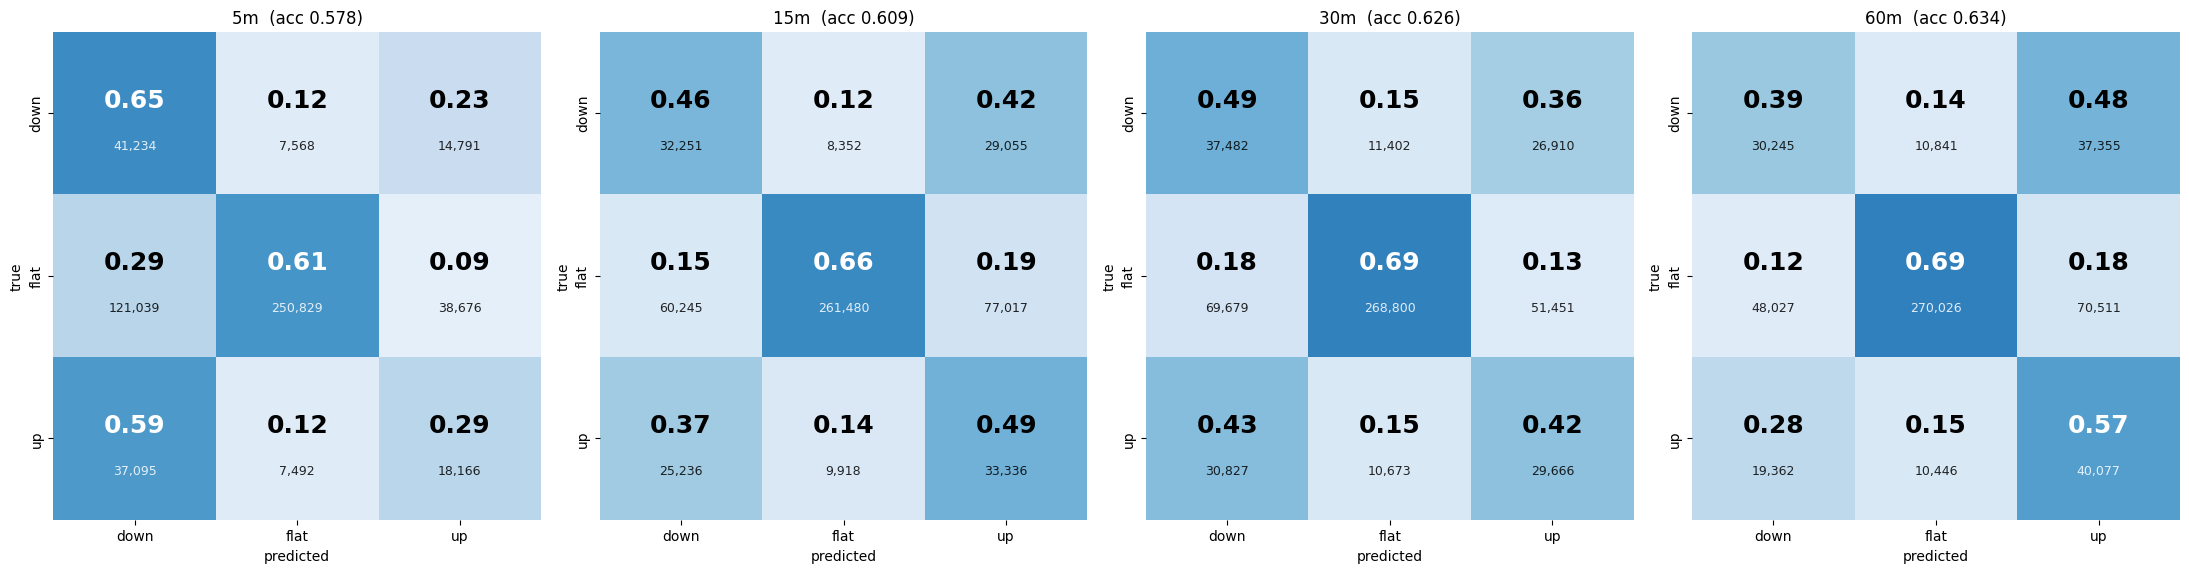

In [ ]:
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_recall_fscore_support)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                         num_workers=2, pin_memory=True)
print(f'Total windows in test_ds: {len(test_ds):,}')

class_names = ['down', 'flat', 'up']

# ---- Collect predictions for all four horizons ----
results_eval = {}
for h_idx, h in enumerate(HORIZONS):
    ckpt = torch.load(results_meta[h]['ckpt'], weights_only=False)
    model_h = LSTMJumpPredictor(
        n_features=len(FEATURE_COLS),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        n_classes=3,
        dropout=DROPOUT,
    ).to(DEVICE)
    model_h.load_state_dict(ckpt['model_state_dict'])
    model_h.eval()

    all_logits, all_y = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            logits = model_h(xb).cpu().numpy()
            all_logits.append(logits)
            all_y.append(yb.numpy()[:, h_idx])

    logits = np.concatenate(all_logits, axis=0)
    y      = np.concatenate(all_y, axis=0)
    pred   = logits.argmax(axis=-1)
    results_eval[h] = {'y': y, 'pred': pred,
                       'best_epoch': ckpt['best_epoch']}
    print(f'  horizon {h}m: evaluated on {len(y):,} samples '
          f'(best epoch {ckpt["best_epoch"]})')

# ---- Per-class tabular metrics (matches the screenshot's text block) ----
for h in HORIZONS:
    y, pred = results_eval[h]['y'], results_eval[h]['pred']
    prec, rec, f1, sup = precision_recall_fscore_support(
        y, pred, labels=[0, 1, 2], zero_division=0)
    print(f'\n--- {h}m per-class metrics ---')
    print(f'{"class":<8}{"precision":>12}{"recall":>10}{"f1":>10}{"support":>10}')
    for c_idx, cname in enumerate(class_names):
        print(f'{cname:<8}{prec[c_idx]:>12.6f}{rec[c_idx]:>10.6f}'
              f'{f1[c_idx]:>10.6f}{sup[c_idx]:>10,}')

# ---- 4-panel confusion-matrix plot (matches the screenshot's heatmaps) ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

for ax, h in zip(axes, HORIZONS):
    y, pred = results_eval[h]['y'], results_eval[h]['pred']
    acc = accuracy_score(y, pred)
    cm  = confusion_matrix(y, pred, labels=[0, 1, 2])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)   # row-normalized

    # Build the heatmap without text first, then add custom-sized annotations
    sns.heatmap(cm_norm, annot=False, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar=False, ax=ax, square=True, vmin=0, vmax=1)

    # Add per-cell text manually so we can control size per line
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            # Pick contrasting color depending on cell darkness
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j + 0.5, i + 0.42, f'{cm_norm[i, j]:.2f}',
                    ha='center', va='center',
                    fontsize=18, fontweight='bold', color=color)
            ax.text(j + 0.5, i + 0.70, f'{cm[i, j]:,}',
                    ha='center', va='center',
                    fontsize=9, color=color, alpha=0.85)

    ax.set_title(f'{h}m  (acc {acc:.3f})', fontsize=12)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')

plt.tight_layout()
plt.show()


LightGBM test rows: 12,760,360

  loaded /content/drive/MyDrive/CS1090B/project/data/models/lgbm_jump3_5m.txt
  horizon 5m: evaluated on 12,760,360 samples

  loaded /content/drive/MyDrive/CS1090B/project/data/models/lgbm_jump3_15m.txt
  horizon 15m: evaluated on 12,760,360 samples

  loaded /content/drive/MyDrive/CS1090B/project/data/models/lgbm_jump3_30m.txt
  horizon 30m: evaluated on 12,760,360 samples

  loaded /content/drive/MyDrive/CS1090B/project/data/models/lgbm_jump3_60m.txt
  horizon 60m: evaluated on 12,760,360 samples

=== horizon = 5m ===
balanced acc : 0.5260
f1 macro     : 0.4748
              precision    recall  f1-score   support

   down (-1)     0.2335    0.4130    0.2983   1169905
 no jump (0)     0.9293    0.7675    0.8407  10423338
     up (+1)     0.2227    0.3975    0.2855   1167117

    accuracy                         0.7011  12760360
   macro avg     0.4618    0.5260    0.4748  12760360
weighted avg     0.8009    0.7011    0.7402  12760360


=== horizon = 1

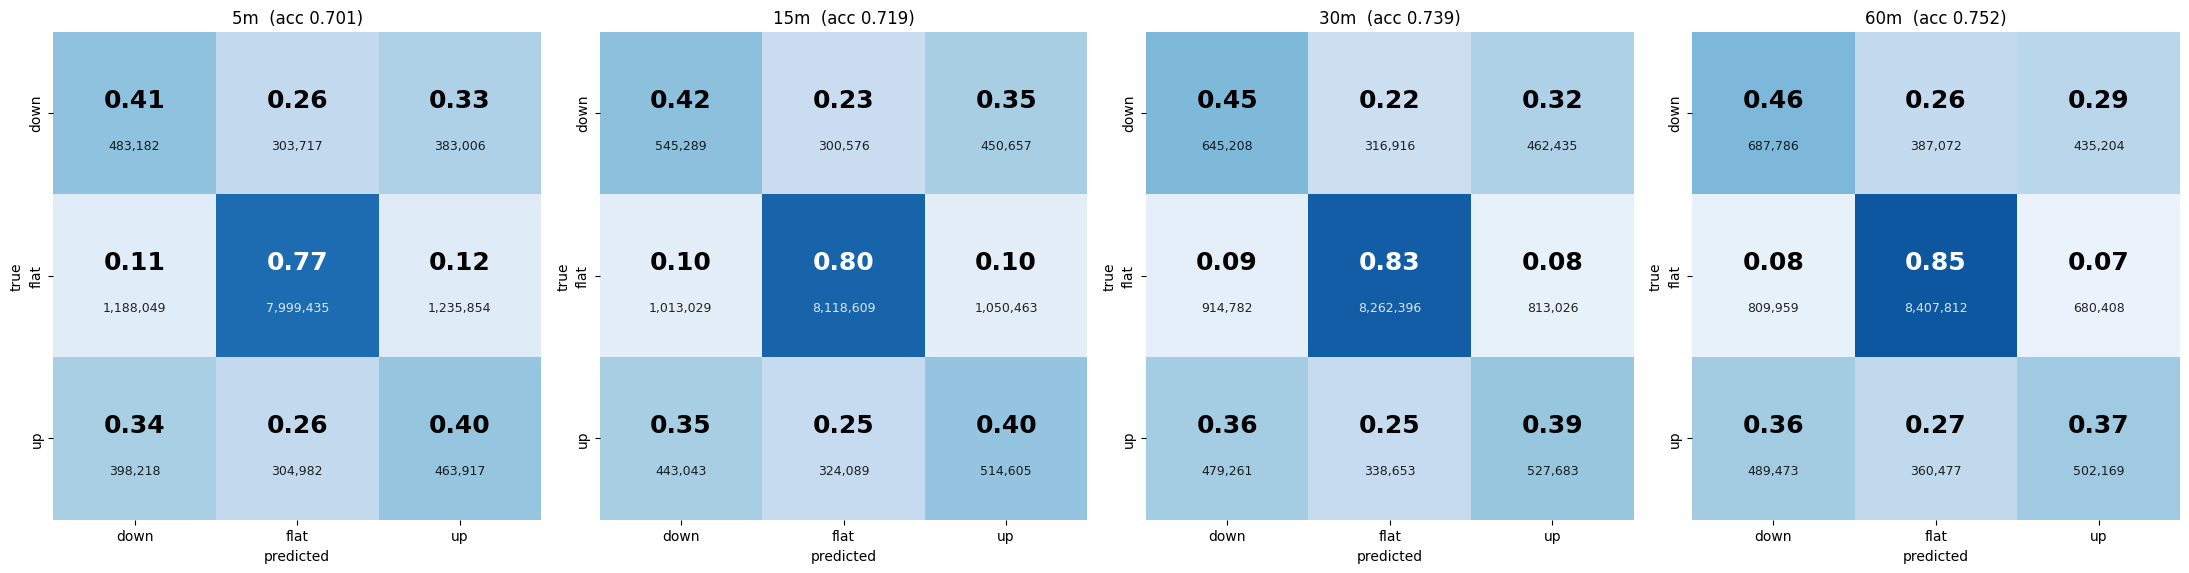

In [ ]:
import os
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_recall_fscore_support,
                              balanced_accuracy_score, f1_score,
                              classification_report)

MODEL_DIR = os.path.join(DATA_ROOT, 'models')

# ---- Build test feature matrix in the same way training did ----
test_mask = df['split'] == 'test'
X_test = df.loc[test_mask, FEATURE_COLS]
print(f'LightGBM test rows: {len(X_test):,}')

class_names = ['down', 'flat', 'up']
label_map = {-1.0: 0, 0.0: 1, 1.0: 2}

# ---- Load each LightGBM model and evaluate ----
results_lgbm = {}
for h in HORIZONS:
    model_path = os.path.join(MODEL_DIR, f'lgbm_jump3_{h}m.txt')
    booster = lgb.Booster(model_file=model_path)
    print(f'\n  loaded {model_path}')

    # Predict probabilities, then take argmax for class predictions
    proba = booster.predict(X_test)                        # [N, 3]
    pred  = proba.argmax(axis=1)                            # [N]
    y     = df.loc[test_mask, f'jump3_{h}m'].map(label_map).astype(np.int8).values

    results_lgbm[h] = {'y': y, 'pred': pred, 'proba': proba}
    print(f'  horizon {h}m: evaluated on {len(y):,} samples')

# ---- Per-class tabular metrics ----
for h in HORIZONS:
    y, pred = results_lgbm[h]['y'], results_lgbm[h]['pred']
    print(f'\n=== horizon = {h}m ===')
    print(f'balanced acc : {balanced_accuracy_score(y, pred):.4f}')
    print(f'f1 macro     : {f1_score(y, pred, average="macro"):.4f}')
    print(classification_report(y, pred,
                                target_names=['down (-1)', 'no jump (0)', 'up (+1)'],
                                digits=4))

# ---- 4-panel confusion-matrix plot (same style as LSTM) ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

for ax, h in zip(axes, HORIZONS):
    y, pred = results_lgbm[h]['y'], results_lgbm[h]['pred']
    acc = accuracy_score(y, pred)
    cm  = confusion_matrix(y, pred, labels=[0, 1, 2])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=False, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar=False, ax=ax, square=True, vmin=0, vmax=1)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j + 0.5, i + 0.42, f'{cm_norm[i, j]:.2f}',
                    ha='center', va='center',
                    fontsize=18, fontweight='bold', color=color)
            ax.text(j + 0.5, i + 0.70, f'{cm[i, j]:,}',
                    ha='center', va='center',
                    fontsize=9, color=color, alpha=0.85)

    ax.set_title(f'{h}m  (acc {acc:.3f})', fontsize=12)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')

plt.tight_layout()
plt.show()

In [3]:
import os
import lightgbm as lgb
import numpy as np
import pandas as pd
import torch
import joblib
from tqdm.auto import tqdm

DATA_ROOT = '/content/drive/MyDrive/CS1090B/project/data'
MODEL_DIR = os.path.join(DATA_ROOT, 'models')

# ---- Load FEATURE_COLS directly ----
FEATURE_COLS = joblib.load(os.path.join(MODEL_DIR, 'feature_cols.joblib'))
print(f'Loaded {len(FEATURE_COLS)} feature columns')

# ---- Load the full feature dataframe ----
df = pd.read_parquet(os.path.join(DATA_ROOT, 'all_trades_features.parquet'))
df['created_time'] = pd.to_datetime(df['created_time'], utc=True)
df['taker_side_int'] = (df['taker_side'] == 'yes').astype(np.int8)
print(f'Loaded {len(df):,} rows')

HORIZONS = [5, 15, 30, 60]

X_full = df[FEATURE_COLS]

lgbm_probas = {}
for h in tqdm(HORIZONS, desc='LightGBM'):
    booster = lgb.Booster(model_file=os.path.join(MODEL_DIR, f'lgbm_jump3_{h}m.txt'))
    proba = booster.predict(X_full).astype(np.float32)
    lgbm_probas[h] = proba

print(f'LightGBM predictions complete. '
      f'Memory: {sum(p.nbytes for p in lgbm_probas.values()) / 1e9:.2f} GB')

Loaded 41 feature columns
Loaded 63,801,798 rows


LightGBM:   0%|          | 0/4 [00:00<?, ?it/s]

LightGBM predictions complete. Memory: 3.06 GB


In [10]:
import math, time

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEQ_LEN = 32
BATCH_SIZE = 4096

# ---- Pull normalization stats from any LSTM checkpoint (all four share them) ----
sample_ckpt = torch.load(os.path.join(MODEL_DIR, 'lstm_jump3_5m.pt'),
                          map_location='cpu', weights_only=False)
feat_mean = sample_ckpt['feat_mean']    # np.ndarray, shape (n_features,)
feat_std  = sample_ckpt['feat_std']
config    = sample_ckpt['config']
HIDDEN_SIZE = config['hidden_size']
NUM_LAYERS  = config['num_layers']
DROPOUT     = config['dropout']
print(f'LSTM config: hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}, seq_len={SEQ_LEN}')

# ---- Sort by ticker, time (should already be sorted but cheap to verify) ----
df = df.sort_values(['ticker', 'created_time'], kind='stable').reset_index(drop=True)

# ---- Pre-normalize feature matrix once, ~10 GB for 64M rows ----
print('Normalizing features...')
feats = ((df[FEATURE_COLS].values - feat_mean) / feat_std).astype(np.float32)
feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)
print(f'feats shape: {feats.shape}, {feats.nbytes / 1e9:.2f} GB')

# ---- Identify ticker boundaries → valid window-end positions ----
codes = pd.factorize(df['ticker'])[0]
change = np.where(np.diff(codes) != 0)[0] + 1
starts = np.concatenate([[0], change])
ends   = np.concatenate([change, [len(df)]])

valid_t = []
for s, e in zip(starts, ends):
    first_t = s + SEQ_LEN - 1   # window [s..s+31] ends at s+31
    if first_t < e:
        valid_t.append(np.arange(first_t, e))
valid_t = np.concatenate(valid_t) if valid_t else np.array([], dtype=np.int64)
print(f'Valid window-end positions: {len(valid_t):,} '
      f'(of {len(df):,}, i.e. {len(valid_t) / len(df):.1%})')

# ---- Container: full (N, 3) per horizon, NaN where no window ----
lstm_probas = {h: np.full((len(df), 3), np.nan, dtype=np.float32) for h in HORIZONS}

# ---- Per-horizon model load and batched inference ----
for h in HORIZONS:
    print(f'\n--- horizon {h}m ---')
    ckpt_path = os.path.join(MODEL_DIR, f'lstm_jump3_{h}m.pt')
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

    model_h = LSTMJumpPredictor(
        n_features=len(FEATURE_COLS),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        n_classes=3,
        dropout=DROPOUT,
    ).to(DEVICE)
    model_h.load_state_dict(ckpt['model_state_dict'])
    model_h.eval()

    n_batches = math.ceil(len(valid_t) / BATCH_SIZE)
    t0 = time.time()
    with torch.no_grad():
        for b_idx in range(n_batches):
            batch_t = valid_t[b_idx * BATCH_SIZE : (b_idx + 1) * BATCH_SIZE]
            # Build windows: shape [B, SEQ_LEN, F]
            # Each row of `windows` is the slice feats[t-31:t+1]
            B = len(batch_t)
            windows = np.empty((B, SEQ_LEN, feats.shape[1]), dtype=np.float32)
            for i, t in enumerate(batch_t):
                windows[i] = feats[t - SEQ_LEN + 1 : t + 1]
            xb = torch.from_numpy(windows).to(DEVICE, non_blocking=True)
            logits = model_h(xb)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            lstm_probas[h][batch_t] = probs

            if b_idx % 200 == 0:
                rate = (b_idx + 1) * BATCH_SIZE / (time.time() - t0)
                eta_min = (len(valid_t) - (b_idx + 1) * BATCH_SIZE) / rate / 60
                print(f'  batch {b_idx:>5}/{n_batches}  '
                      f'rate={rate:,.0f} trades/s  eta={eta_min:.1f} min')

    print(f'  horizon {h}m done in {(time.time() - t0)/60:.1f} min')

    # Free GPU memory between horizons
    del model_h
    torch.cuda.empty_cache()

print('\nLSTM predictions complete.')

LSTM config: hidden=192, layers=2, seq_len=32
Normalizing features...
feats shape: (63801798, 41), 10.46 GB
Valid window-end positions: 58,315,451 (of 63,801,798, i.e. 91.4%)

--- horizon 5m ---
  batch     0/14238  rate=12,060 trades/s  eta=80.6 min
  batch   200/14238  rate=40,771 trades/s  eta=23.5 min
  batch   400/14238  rate=41,031 trades/s  eta=23.0 min
  batch   600/14238  rate=41,119 trades/s  eta=22.6 min
  batch   800/14238  rate=41,155 trades/s  eta=22.3 min
  batch  1000/14238  rate=41,178 trades/s  eta=21.9 min
  batch  1200/14238  rate=41,194 trades/s  eta=21.6 min
  batch  1400/14238  rate=41,207 trades/s  eta=21.3 min
  batch  1600/14238  rate=41,217 trades/s  eta=20.9 min
  batch  1800/14238  rate=41,225 trades/s  eta=20.6 min
  batch  2000/14238  rate=41,232 trades/s  eta=20.3 min
  batch  2200/14238  rate=41,237 trades/s  eta=19.9 min
  batch  2400/14238  rate=41,240 trades/s  eta=19.6 min
  batch  2600/14238  rate=41,244 trades/s  eta=19.3 min
  batch  2800/14238  

In [11]:
# ---- Assemble the output dataframe ----
out_cols = {
    'ticker':       df['ticker'].values,
    'created_time': df['created_time'].values,
}

# class 0 = down, class 1 = no_jump, class 2 = up (this matches the training label_map)
class_names = ['down', 'no_jump', 'up']

for h in HORIZONS:
    for cls_idx, cls_name in enumerate(class_names):
        out_cols[f'probability_{cls_name}_{h}minutes_lgbm'] = lgbm_probas[h][:, cls_idx]
        out_cols[f'probability_{cls_name}_{h}minutes_lstm'] = lstm_probas[h][:, cls_idx]

out_df = pd.DataFrame(out_cols)
print(f'out_df shape: {out_df.shape}')
print(f'columns: {list(out_df.columns)}')
print(f'NaN counts:')
print(out_df.isna().sum())

# ---- Save ----
out_path = os.path.join(DATA_ROOT, 'stacking_predictions.parquet')
out_df.to_parquet(out_path, engine='pyarrow', compression='zstd', index=False)
print(f'\nSaved to {out_path} ({os.path.getsize(out_path) / 1e9:.2f} GB)')

out_df shape: (63801798, 26)
columns: ['ticker', 'created_time', 'probability_down_5minutes_lgbm', 'probability_down_5minutes_lstm', 'probability_no_jump_5minutes_lgbm', 'probability_no_jump_5minutes_lstm', 'probability_up_5minutes_lgbm', 'probability_up_5minutes_lstm', 'probability_down_15minutes_lgbm', 'probability_down_15minutes_lstm', 'probability_no_jump_15minutes_lgbm', 'probability_no_jump_15minutes_lstm', 'probability_up_15minutes_lgbm', 'probability_up_15minutes_lstm', 'probability_down_30minutes_lgbm', 'probability_down_30minutes_lstm', 'probability_no_jump_30minutes_lgbm', 'probability_no_jump_30minutes_lstm', 'probability_up_30minutes_lgbm', 'probability_up_30minutes_lstm', 'probability_down_60minutes_lgbm', 'probability_down_60minutes_lstm', 'probability_no_jump_60minutes_lgbm', 'probability_no_jump_60minutes_lstm', 'probability_up_60minutes_lgbm', 'probability_up_60minutes_lstm']
NaN counts:
ticker                                      0
created_time                       